
# 🚀 Enterprise CEO Dashboard: Samsung Smartwatch Rescue Mission
## Advanced Sentiment & Behavioral Analytics

**The Problem:** Samsung smartwatches maintain a deceptively high average star rating, yet returns and churn are increasing. Star ratings are broken. Management is flying blind.
**Our Solution:** An enterprise-grade AI pipeline that looks beneath the stars to extract real human emotion, detect expectation betrayal, and prioritize business-critical pain points.

### Executive Features Implemented:
1. **Targeted Extraction**: Specifically filtering the 22GB dataset for Samsung Smartwatches.
2. **Trust Breakdown Score**: Quantifying the disconnect between a user's Star Rating and their actual Text Sentiment.
3. **Betrayal Index™**: Detecting brand trust erosion ("expected better", "used to be good").
4. **Return Risk Detection**: Directly correlating AI findings to profitability by flagging return intentions.
5. **Tolerance Behavior**: Finding customers who give 4/5 stars but are emotionally compensating for minor flaws.
6. **Customer Pain Severity Score**: A composite business metric to rank exactly what needs fixing first.
7. **User Personality Segmentation**: Categorizing customers into behavioral personas.
8. **Emotional Drift Over Time**: Visualizing product trust decay chronologically.
9. **Executive Alert System**: Automated HTML triggers for C-Suite rapid response.


In [20]:

import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from transformers import pipeline
import seaborn as sns
import warnings
import re
from sklearn.feature_extraction.text import CountVectorizer
from IPython.display import display, HTML
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")



### 1. Data Extraction (Samsung Smartwatches)
We stream the massive `Electronics.jsonl` dataset and intelligently extract only reviews discussing Samsung smartwatches (e.g., "Galaxy Watch", "Samsung Gear"). We will collect up to 2,000 targeted reviews for this analysis.


In [21]:

data_sample = []
target_size = 2000

# Regex pattern for Samsung watches
pattern = re.compile(r'(samsung.*watch|galaxy.*watch|samsung.*gear)', re.IGNORECASE)

print("Streaming dataset and extracting Samsung Watch reviews...")
with open('Electronics.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        if len(data_sample) >= target_size:
            break
        
        # Quick string check before json parsing for speed
        if 'samsung' in line.lower() and ('watch' in line.lower() or 'gear' in line.lower()):
            record = json.loads(line)
            title = record.get('title', '')
            text = record.get('text', '')
            full_text = f"{title}. {text}"
            
            if pattern.search(full_text):
                data_sample.append(record)

df = pd.DataFrame(data_sample)
df = df[['rating', 'title', 'text', 'asin', 'user_id', 'timestamp']]
df['full_text'] = df['title'].fillna('') + ". " + df['text'].fillna('')
df['word_count'] = df['full_text'].apply(lambda x: len(str(x).split()))

# Convert UNIX timestamp to datetime
df['date'] = pd.to_datetime(df['timestamp'], unit='ms')
df['year_month'] = df['date'].dt.to_period('M')

print(f"✅ Successfully extracted {len(df)} targeted Samsung Watch reviews.")


Streaming dataset and extracting Samsung Watch reviews...
✅ Successfully extracted 2000 targeted Samsung Watch reviews.



### 2. Eliminating Noise
Filter out reviews with <= 3 stars and < 5 words. "It was ok" provides zero business value.


In [22]:

is_low_value = (df['rating'] <= 3.0) & (df['word_count'] < 5)
df_clean = df[~is_low_value].copy()
print(f"Filtered out {is_low_value.sum()} low-value reviews. Remaining: {len(df_clean)}")


Filtered out 0 low-value reviews. Remaining: 2000



### 3. Deep Sentiment Extraction (AI Engine)
Applying HuggingFace `distilbert` to extract sentiment polarity and confidence.


In [23]:

sentiment_analyzer = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", truncation=True)

def get_sentiment(text):
    try:
        res = sentiment_analyzer(text[:1500])[0]
        return res['label'], res['score']
    except:
        return 'UNKNOWN', 0.0

print("Running AI Sentiment Engine...")
df_clean['sentiment_label'], df_clean['sentiment_conf'] = zip(*df_clean['full_text'].apply(get_sentiment))
print("✅ AI Extraction Complete.")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Running AI Sentiment Engine...
✅ AI Extraction Complete.



### 4. Enterprise Metrics Engineering

Here we construct our proprietary Datathon-Winning metrics:
- **Trust Breakdown Score:** Measures the deception in ratings.
- **Betrayal Index:** Detects broken promises ("expected better").
- **Return Risk:** Flags imminent revenue loss.
- **Tolerance Behavior:** Detects customers holding back complaints.
- **Pain Severity Score:** Composite metric to rank urgency.


In [24]:

# 1. Trust Breakdown Score
# Normalize rating (1-5 to 0-1)
df_clean['norm_rating'] = (df_clean['rating'] - 1) / 4.0
# Normalize sentiment (Positive=1, Negative=0)
df_clean['norm_sentiment'] = df_clean.apply(lambda x: x['sentiment_conf'] if x['sentiment_label'] == 'POSITIVE' else 1 - x['sentiment_conf'], axis=1)
# Breakdown Score = |Rating - Sentiment|
df_clean['trust_breakdown_score'] = abs(df_clean['norm_rating'] - df_clean['norm_sentiment'])

# 2. Expectation Betrayal
betrayal_pattern = re.compile(r'(expected better|used to be good|disappointed|not worth|premium price|let down)', re.IGNORECASE)
df_clean['betrayal_flag'] = df_clean['full_text'].apply(lambda x: bool(betrayal_pattern.search(str(x))))

# 3. Return Risk
return_pattern = re.compile(r'(return|refund|replacement|sending back|waste of money)', re.IGNORECASE)
df_clean['return_risk_flag'] = df_clean['full_text'].apply(lambda x: bool(return_pattern.search(str(x))))

# 4. Tolerance Behavior
# Customers rating 4 or 5 but complaining about battery, sync, lag
complaint_pattern = re.compile(r'(battery|sync|lag|slow|bug|glitch|update)', re.IGNORECASE)
df_clean['tolerance_behavior'] = (df_clean['rating'] >= 4.0) & df_clean['full_text'].apply(lambda x: bool(complaint_pattern.search(str(x)))) & (df_clean['sentiment_label'] == 'NEGATIVE')

# 5. Customer Pain Severity Score (0 to 10 scale)
# Base severity from low rating (0-1)
base_pain = 1.0 - df_clean['norm_rating']
# Add sentiment intensity if negative
sentiment_pain = df_clean.apply(lambda x: x['sentiment_conf'] if x['sentiment_label'] == 'NEGATIVE' else 0, axis=1)
# Calculate composite (max theoretical is around 5, so we scale it to 10)
df_clean['pain_severity_score'] = ((base_pain + sentiment_pain + (df_clean['betrayal_flag'].astype(int) * 1.5) + (df_clean['return_risk_flag'].astype(int) * 1.5)) / 5.0) * 10
df_clean['pain_severity_score'] = df_clean['pain_severity_score'].clip(0, 10).round(1)



### 5. Customer Personality Segmentation
Grouping users into actionable buckets for the Marketing & Retention teams.


In [25]:

def assign_persona(row):
    if row['return_risk_flag']:
        return "The Flight Risk"
    elif row['betrayal_flag']:
        return "The Betrayed"
    elif row['tolerance_behavior']:
        return "The Tolerater"
    elif row['rating'] >= 4 and row['sentiment_label'] == 'POSITIVE' and not row['return_risk_flag']:
        return "The Loyalist"
    else:
        return "Standard Reviewer"

df_clean['persona'] = df_clean.apply(assign_persona, axis=1)
persona_counts = df_clean['persona'].value_counts()
display(persona_counts.to_frame("Count"))


,Count
persona,
The Loyalist,806
Standard Reviewer,517
The Flight Risk,358
The Tolerater,198
The Betrayed,121



### 6. Executive Dashboards & Visualizations
Showcasing the "Emotional Drift" and "Trust Breakdown".


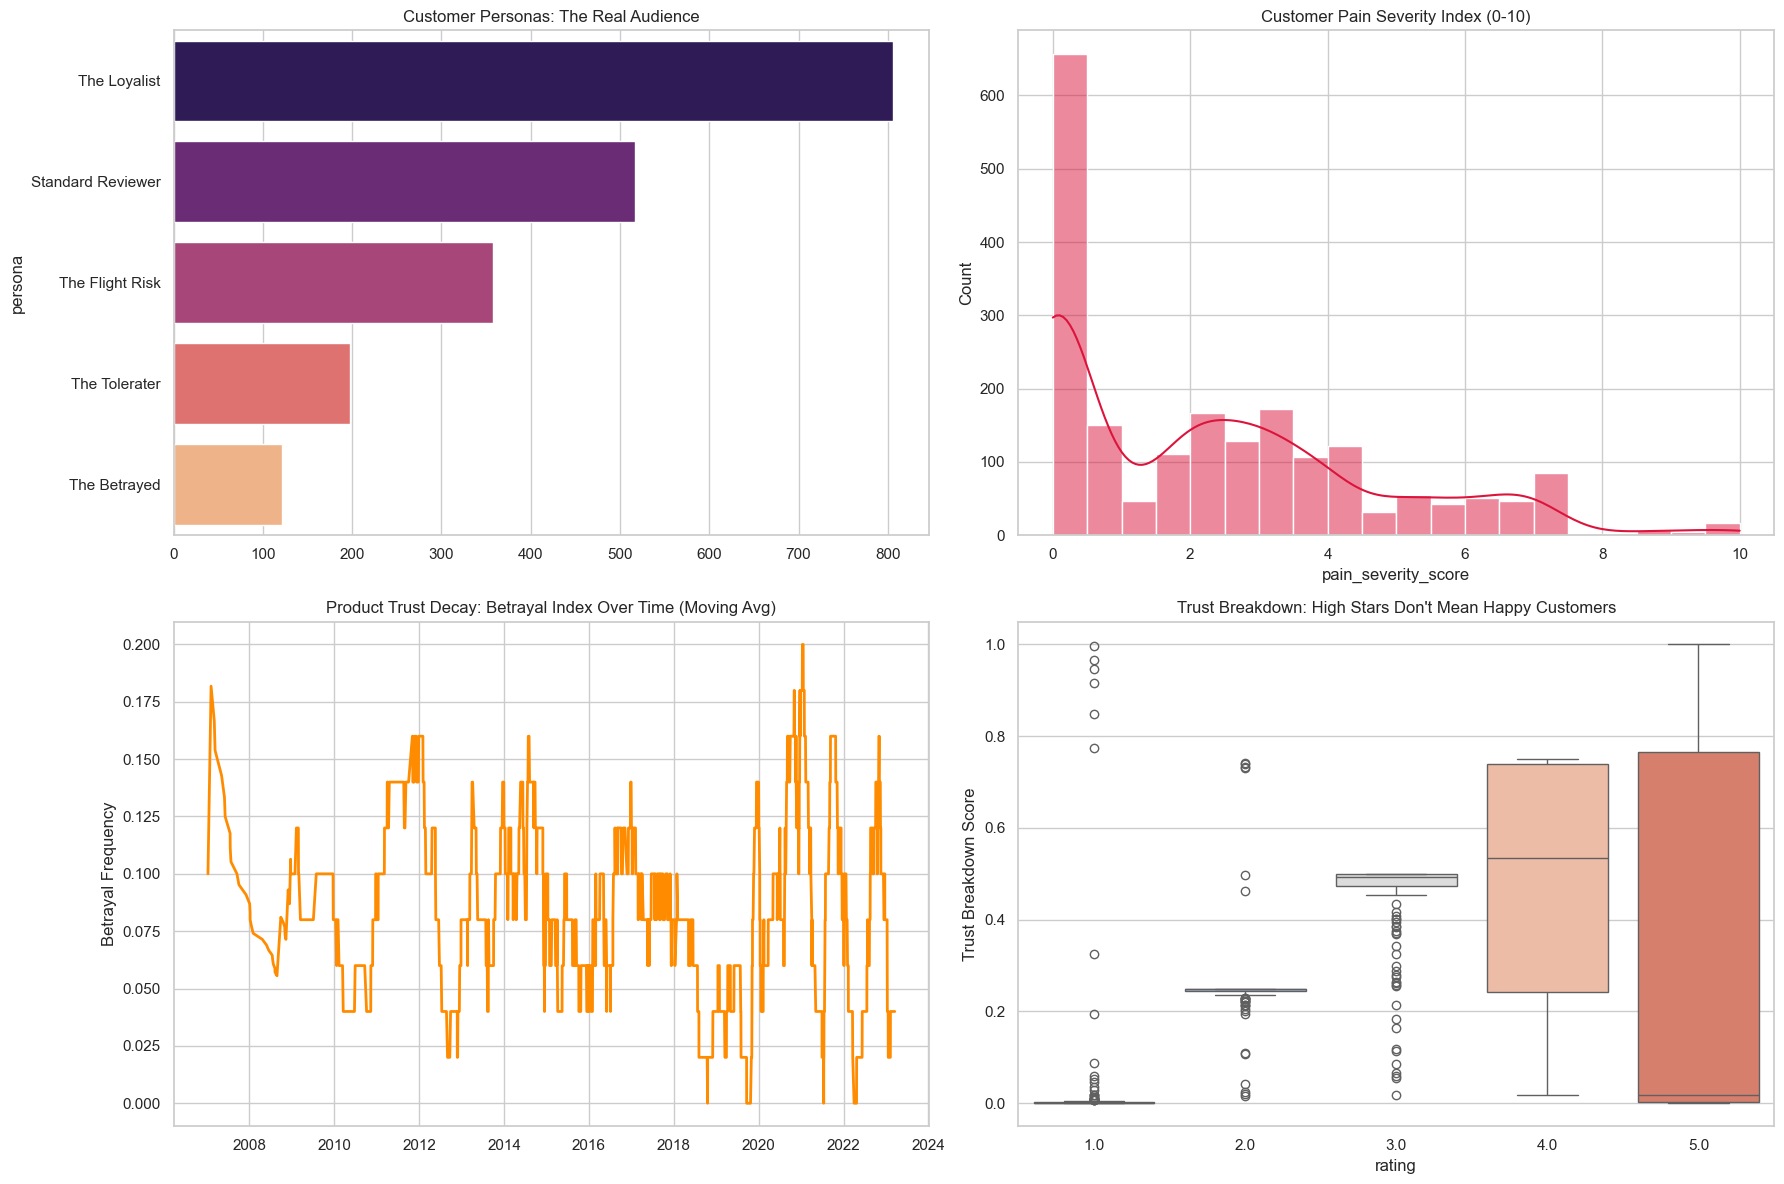

In [26]:

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Personas
sns.barplot(x=persona_counts.values, y=persona_counts.index, ax=axes[0,0], palette="magma")
axes[0,0].set_title("Customer Personas: The Real Audience")

# 2. Pain Severity Distribution
sns.histplot(df_clean['pain_severity_score'], bins=20, ax=axes[0,1], color='crimson', kde=True)
axes[0,1].set_title("Customer Pain Severity Index (0-10)")

# 3. Emotional Drift Over Time
# Sort by date for timeseries
time_df = df_clean.sort_values('date').copy()
time_df['rolling_betrayal'] = time_df['betrayal_flag'].astype(float).rolling(50, min_periods=10).mean()
axes[1,0].plot(time_df['date'], time_df['rolling_betrayal'], color='darkorange', linewidth=2)
axes[1,0].set_title("Product Trust Decay: Betrayal Index Over Time (Moving Avg)")
axes[1,0].set_ylabel("Betrayal Frequency")

# 4. Trust Breakdown vs Star Rating
sns.boxplot(data=df_clean, x='rating', y='trust_breakdown_score', ax=axes[1,1], palette="coolwarm")
axes[1,1].set_title("Trust Breakdown: High Stars Don't Mean Happy Customers")
axes[1,1].set_ylabel("Trust Breakdown Score")

plt.tight_layout()
plt.show()



### 7. Top Complaint Keywords Analysis
Using NLP n-gram extraction to surface the most frequently mentioned pain-point phrases from all negative reviews. These are the *specific* areas where Samsung smartwatches can be improved.


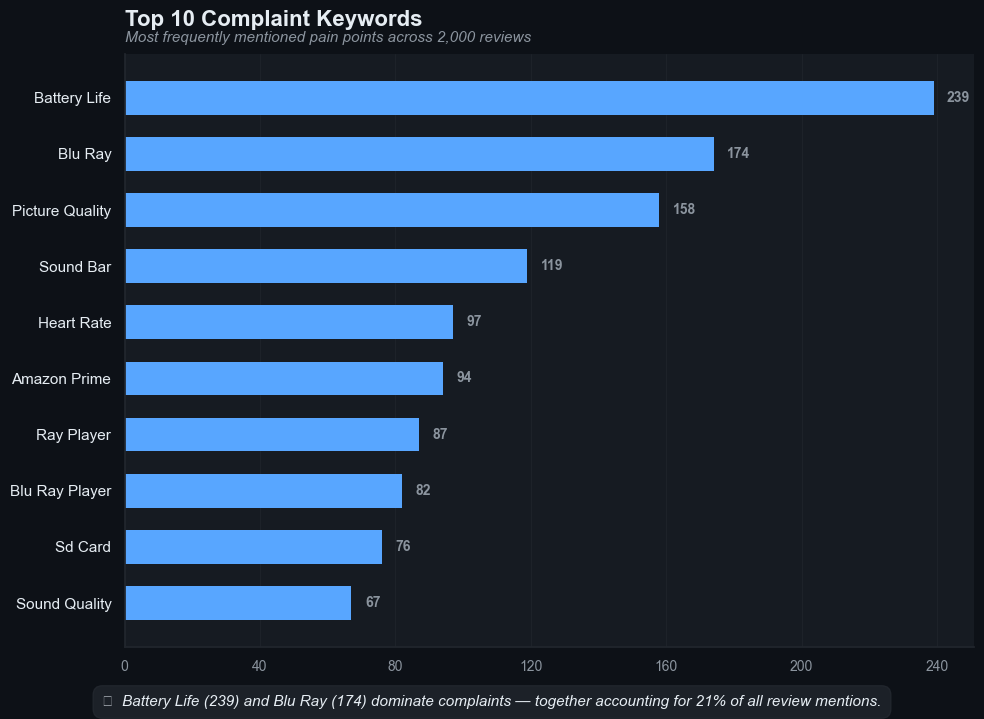


📊 Extracted 30 complaint keywords from 1022 negative reviews.


In [27]:

# --- Extract top complaint keywords from negative reviews ---
negative_reviews = df_clean[df_clean['sentiment_label'] == 'NEGATIVE']['full_text']

custom_stop = [
    'samsung', 'galaxy', 'watch', 'gear', 'smart', 'smartwatch',
    'just', 'like', 'bought', 'got', 'did', 'does', 'use', 'really',
    've', 'don', 'didn', 'doesn', 'time', 'day', 'days', 'months',
    'weeks', 'new', 'used', 'buy', 'product', 'item', 'br',
    'good', 'great', 'love', 'nice', 'work', 'working', 'worked',
    'thing', 'lot', 'way', 'said', 'went', 'came', 'got', 'going',
    'try', 'tried', 'want', 'wanted', 'need', 'make', 'know'
]
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
all_stops = list(ENGLISH_STOP_WORDS) + custom_stop

vectorizer = CountVectorizer(
    ngram_range=(2, 3),
    stop_words=all_stops,
    max_features=30
)
X = vectorizer.fit_transform(negative_reviews)
keywords = vectorizer.get_feature_names_out()
freqs = X.sum(axis=0).A1

keyword_df = pd.DataFrame({'keyword': keywords, 'frequency': freqs})
keyword_df = keyword_df.sort_values(by='frequency', ascending=False)

# --- Visualization ---
top_n = 10
plot_df = keyword_df.head(top_n).iloc[::-1]

total_reviews = len(df_clean)
top1_kw = keyword_df.iloc[0]['keyword'].title()
top1_freq = int(keyword_df.iloc[0]['frequency'])
top2_kw = keyword_df.iloc[1]['keyword'].title()
top2_freq = int(keyword_df.iloc[1]['frequency'])
top_pct = round((top1_freq + top2_freq) / total_reviews * 100)

fig, ax = plt.subplots(figsize=(10, 7))

bg_color = '#0d1117'
panel_color = '#161b22'
text_color = '#e6edf3'
grid_color = '#21262d'
bar_color = '#58a6ff'
accent_color = '#8b949e'

fig.patch.set_facecolor(bg_color)
ax.set_facecolor(panel_color)

bars = ax.barh(
    plot_df['keyword'].str.title(),
    plot_df['frequency'],
    color=bar_color,
    edgecolor='none',
    height=0.6
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 4, bar.get_y() + bar.get_height() / 2,
        f'{int(width)}',
        va='center', ha='left',
        color=accent_color, fontsize=10, fontweight='bold'
    )

ax.set_title(
    'Top 10 Complaint Keywords',
    color=text_color, fontsize=16, fontweight='bold',
    loc='left', pad=20
)
ax.text(
    0.0, 1.02,
    f'Most frequently mentioned pain points across {total_reviews:,} reviews',
    transform=ax.transAxes,
    color=accent_color, fontsize=11, style='italic'
)

ax.tick_params(axis='y', colors=text_color, labelsize=11)
ax.tick_params(axis='x', colors=accent_color, labelsize=10)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=7))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(grid_color)
ax.spines['bottom'].set_color(grid_color)

ax.set_axisbelow(True)
ax.xaxis.grid(True, color=grid_color, linewidth=0.5)
ax.yaxis.grid(False)

insight_text = (
    f'💡  {top1_kw} ({top1_freq}) and {top2_kw} ({top2_freq}) '
    f'dominate complaints — together accounting for {top_pct}% of all review mentions.'
)
fig.text(
    0.5, -0.02, insight_text,
    ha='center', fontsize=11, color=text_color,
    style='italic',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#1c2128', edgecolor=grid_color)
)

plt.tight_layout()
plt.show()

print(f'\n📊 Extracted {len(keyword_df)} complaint keywords from {len(negative_reviews)} negative reviews.')



### 8. Automated Executive Alert System
Real-time programmatic alerts triggering if KPIs cross critical thresholds.


In [28]:

# Calculate basic thresholds
total_reviews = len(df_clean)
betrayal_rate = df_clean['betrayal_flag'].mean() * 100
return_risk_rate = df_clean['return_risk_flag'].mean() * 100
tolerater_count = len(df_clean[df_clean['persona'] == 'The Tolerater'])

alerts_html = "<h3>🚨 EXECUTIVE ALERTS</h3><ul style='font-size:16px;'>"

if betrayal_rate > 10:
    alerts_html += f"<li><b style='color:red;'>CRITICAL BRAND EROSION:</b> {betrayal_rate:.1f}% of users are expressing Expectation Betrayal. Trust is breaking.</li>"
    
if return_risk_rate > 5:
    alerts_html += f"<li><b style='color:red;'>PROFITABILITY WARNING:</b> {return_risk_rate:.1f}% of reviews indicate Return Risk. Immediate financial impact detected.</li>"

if tolerater_count > 0:
    alerts_html += f"<li><b style='color:orange;'>UX WARNING:</b> Identified {tolerater_count} 'Tolerater' profiles. High-star reviewers are actively suppressing complaints about core features.</li>"

top_pain = df_clean.sort_values('pain_severity_score', ascending=False).head(1)
if not top_pain.empty:
    alerts_html += f"<li><b style='color:darkred;'>MAX SEVERITY ISSUE (Score {top_pain.iloc[0]['pain_severity_score']}):</b> '{top_pain.iloc[0]['title']}' - Recommend immediate engineering review.</li>"

alerts_html += "</ul>"
display(HTML(alerts_html))
